In [1]:
import warnings
import math
from functools import partial
from pathlib import Path
from typing import Callable

import jax
from jax import Array
from jax import scipy as jsp
from jax import numpy as jnp

import dynamiqs as dq

from blueprint.qubits import Fluxonium, HarmonicOscillator
from blueprint.devices import Device
from blueprint.couplings import get_capacitive_coupling
from blueprint.util.index import get_branch_inds
from blueprint.util.quantum import to_denstiy_matrix


from matplotlib import pyplot as plt

/Users/varb2323/Projects/blueprint/.venv/lib/python3.12/site-packages/qutip/__init__.py:71: UserWarning: Runtime cython compilation does not work on Python 3.12.
  warnings.warn(


In [2]:
def get_figsize(
    columns: int = 1, fig_width=None, fig_height=None, width_scale=1.0, height_scale=1.0
):
    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf

    if columns not in [1, 2]:
        raise ValueError("Plotting in three-column style is not supported")

    MAX_HEIGHT = 8.0
    golden_ratio = 0.5 * (1 + math.sqrt(5))

    if not fig_width:
        fig_width = (
            3.4 if columns == 1 else 7
        )  # one-column width is ~8.6cm, double-column is ~17.8cm

    fig_height = fig_height or fig_width / golden_ratio  # height in inches

    if fig_height > MAX_HEIGHT:
        warnings.warn(
            "Figure height {} is too large, setting to {}"
            "inches instead".format(fig_height, MAX_HEIGHT)
        )

    width = fig_width * width_scale
    height = fig_height * height_scale
    figsize = (width, height)
    return figsize


def get_rc_params(**kwargs):
    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf
    params = {
        # "backend": "ps",
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "text.usetex": False,
        "font.family": "serif",
    }
    params.update(kwargs)
    return params

In [3]:
def step_envelope(t: float | Array, /, pad_time: float, hold_time: float) -> Array:
    hold_times = (t > pad_time) & (t <= pad_time + hold_time)
    envelope = jnp.where(hold_times, 1, 0)
    return envelope


def gaussian_filter(
    t: float, /, edge_times: Array, input_amps: Array, timescale: float
) -> Array:
    erfs = jsp.special.erf((t - edge_times) * timescale)
    erf_diffs = -0.5 * jnp.diff(erfs)
    erf_diffs /= jnp.sum(erf_diffs)
    output_amps = jnp.sum(input_amps * erf_diffs, axis = -1)

    return output_amps

def readout_pulse(
    t: float,
    max_amplitude: float | Array,
    drive_frequency: float | Array,
    pad_time: float,
    hold_time: float,
) -> Callable:
    max_amplitudes = jnp.atleast_1d(max_amplitude)
    drive_frequencies = jnp.atleast_1d(drive_frequency)

    envelope = step_envelope(t, pad_time, hold_time)
    sin_term = jnp.sin(drive_frequencies * t)
    drive_amplitudes = max_amplitudes[..., None] * sin_term[None, ]
    amplitudes = drive_amplitudes * envelope
    return jnp.squeeze(amplitudes)

def get_filtered_readout_pulse(
    max_amplitude: float | Array,
    drive_frequency: float | Array,
    pad_time: float,
    hold_time: float,
    decay_time: float,
    gaussian_std: float,
    num_pixels: int,
) -> Callable[[float], float | Array]:
    gate_time = hold_time + pad_time + decay_time
    edge_times = jnp.linspace(0, gate_time, num_pixels + 1)
    times = 0.5 * (edge_times[1:] + edge_times[:-1])

    envelope = step_envelope(times, pad_time, hold_time)
    max_amplitudes = jnp.atleast_1d(max_amplitude)
    drive_frequencies = jnp.atleast_1d(drive_frequency)

    sin_terms = jnp.sin(drive_frequencies[..., None] * times[None, ...])
    drive_amplitudes = max_amplitudes[..., None, None] * sin_terms[None, ...]
    amplitudes = jnp.squeeze(drive_amplitudes * envelope)
    timescale = 1 / (math.sqrt(2) * gaussian_std)

    pulse = partial(
        gaussian_filter,
        edge_times=edge_times,
        input_amps=amplitudes,
        timescale=timescale,
    )

    return pulse

In [4]:
def get_hamiltonian(device):
    hamiltonian = device.get_hamiltonian()
    hamiltonian_arr = dq.constant(hamiltonian)

    drive_terms = device.get_drive_hamiltonian_terms(finalize=True)
    for prefactor, operator in drive_terms:
        modulated_arr = dq.modulated(prefactor, operator)
        hamiltonian_arr += modulated_arr

    return hamiltonian_arr

def get_states(device, state_inds):
    for inds in state_inds:
        _, eig_vec = device.get_eigenstate(*inds)
        state = to_denstiy_matrix(eig_vec)
        yield state

def get_jump_operators(device):
    jump_operator = jnp.zeros((device.dim, device.dim))
    yield jump_operator


In [5]:
# Set the options for the GPU use
USE_GPU: bool = False
DEVICE_IND: int = 0

USE_NETCDF4: bool = True

# Units
GHz = 2 * math.pi
MHz = 1e-3 * 2 * math.pi

ns = 1

# Set up environement
jax.config.update("jax_enable_x64", True)  # Double precision

Set up the notebook directory

In [6]:
notebook_dir = Path.cwd()

Define the fluxonium parameters

In [48]:
# Qubit parameters
QUBIT_LABEL = "fluxonium"
CHARGING_ENERGY: float = 1.0 * GHz
INDUCTIVE_ENERGY: float = 0.275 * GHz
JOSEPHSON_ENERGY: float = 5.0 * GHz
EXT_FLUX: float = 0.5 * 2 * math.pi
FOCK_CUTOFF: int = 1000
QUBIT_DIM: int = 5

Define the resonator parameters

In [49]:
RES_LABEL: str = "resonator"
RES_FREQ: float = 6.75 * GHz
RES_IMPEDANCE: float = 50.0
RES_DECAY_RATE: float = 2 * MHz
RES_THERMAL_PHOTONS: float = 0.0
RES_DIM: int = 20

Define the coupling strength between the fluxonium and the resonator

In [50]:
# Coupling strength
COUP_LABEL = "coupling"
COUP_STRENGTH = 100 * MHz

Set the readout drive parameters

In [51]:
MAX_AMPLITUDE: float = 5 * MHz  # Drive amplitude
PAD_TIME: float = 0 # Time before the pulse starts
HOLD_TIME: float = 250 * ns  # Time the pulse is on


In [52]:
fluxonium = Fluxonium(
    label=QUBIT_LABEL,
    charging_energy=CHARGING_ENERGY,
    inductive_energy=INDUCTIVE_ENERGY,
    josephson_energy=JOSEPHSON_ENERGY,
    ext_flux=EXT_FLUX,
    fock_cutoff=FOCK_CUTOFF,
)

fluxonium.diagonalize(QUBIT_DIM)

In [53]:
resonator = HarmonicOscillator.from_frequency(
    label=RES_LABEL,
    frequency=RES_FREQ,
    impedance=RES_IMPEDANCE,
    dim=RES_DIM,
    decay_rate=RES_DECAY_RATE,
    thermal_photons=RES_THERMAL_PHOTONS,
)

In [54]:
device = Device(fluxonium, resonator)

coupling_strength = COUP_STRENGTH / resonator.charge_zpf
coupling = get_capacitive_coupling(
    label=COUP_LABEL,
    system=fluxonium,
    coupled_system=resonator,
    coupling_strength=coupling_strength,
)
device.add_coupling(coupling)

In [55]:
energies, states = device.get_eigenstates()

ground_inds = jnp.argmax(jnp.abs(states[::RES_DIM]), axis=1)

raise_op = resonator.get_raise_op()
inds = get_branch_inds(states, raise_op, ground_inds)

energies = energies[inds]
states = jnp.transpose(states[:, inds])

energies = energies.reshape(QUBIT_DIM, RES_DIM)
states = states.reshape(QUBIT_DIM, RES_DIM, QUBIT_DIM * RES_DIM)

In [56]:
drive_frequency = 0.5 * (energies[1, 1] - energies[1, 0] + energies[0, 1] - energies[0, 0])

In [57]:
resonator.add_charge_drive(
    label="readout_pulse",
    charge_pulse=readout_pulse,
    drive_frequency=drive_frequency,
    max_amplitude=MAX_AMPLITUDE,
    pad_time=PAD_TIME,
    hold_time=HOLD_TIME,
)

In [58]:
save_times = jnp.linspace(0, 500, 100)

hamiltonian = get_hamiltonian(device)

jump_ops = list(resonator.get_decay_ops())

state_inds = [(0, 0), (1, 0)]
state_list = [to_denstiy_matrix(states[*inds]) for inds in state_inds]
init_states = jnp.stack(state_list)

res_low_op = resonator.get_low_op()
res_number_op = resonator.get_number_op()

exp_ops = [res_low_op, res_number_op]


In [59]:
options=dq.Options(save_states=True, verbose=True)
solver = dq.solver.Tsit5(rtol=1e-8, atol=1e-8, max_steps=1000000)

In [60]:

result = dq.mesolve(
    hamiltonian,
    jump_ops, 
    init_states, 
    save_times, 
    exp_ops=exp_ops,
    solver=solver,
    options=options,   
    
)
print(result)

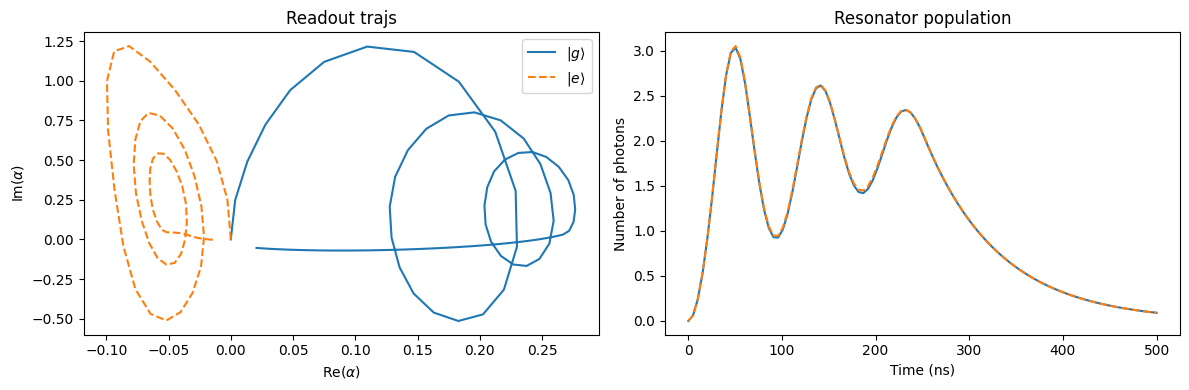

In [ ]:
# === expects in rotating frame
phasespace = result.expects[:, 0, :] * jnp.exp(1j * drive_frequency * save_times)

# === plot
fig, (ax0, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax0.plot(phasespace[0, :250].real, phasespace[0, :250].imag, label=r"$\vert g \rangle$", ls='-')
ax0.plot(phasespace[1, :250].real, phasespace[1, :250].imag, label=r"$\vert e \rangle$", ls='--')

ax2.plot(save_times, result.expects[0, 1, :].real, label=r"$\vert g \rangle$", ls='-')
ax2.plot(save_times, result.expects[1, 1, :].real, label=r"$\vert e \rangle$", ls='--')

ax0.set_title("Readout trajs")
ax0.set_xlabel(r"$\mathrm{Re}(\alpha)$")
ax0.set_ylabel(r"$\mathrm{Im}(\alpha)$")
ax0.legend()

ax2.set_xlabel(r"Time (ns)")
ax2.set_ylabel(r"Number of photons")
ax2.set_title(r"Resonator population")


plt.tight_layout()
plt.show()

In [47]:
phasespace.shape

(2, 100)

In [497]:
max_amplitude: float | Array = jnp.array([0.1, 1, 10]) * MHz
drive_frequency: float | Array = RES_FREQ
pad_time: float = 0
hold_time: float = 500

pulse = get_readout_pulse(
    max_amplitude, drive_frequency, pad_time, hold_time
)

In [498]:
times = jnp.linspace(0, 1000, 10000)
pulse_amps = jax.lax.map(pulse, times)

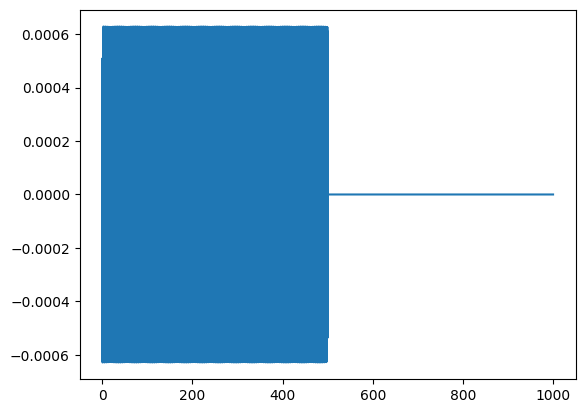

In [499]:
fig, ax = plt.subplots()

ax.plot(times, pulse_amps[:, 0])
plt.show()

In [486]:
max_amplitudes[..., None, None].shape

(3, 1, 1)

In [253]:
jnp.expand_dims(jnp.atleast_1d(0.5), axis=(1, 2)).shape

(1, 1, 1)

In [254]:
amplitudes.shape

(3, 3, 1000)